# Requirements

In [97]:
import matplotlib.pyplot as plt
import numpy as np

In [15]:
rng = np.random.default_rng(seed=1234)

# Operations

Create a square matrix.

In [22]:
A = np.arange(16.0).reshape(4, -1)
A

array([[ 0.,  1.,  2.,  3.],
       [ 4.,  5.,  6.,  7.],
       [ 8.,  9., 10., 11.],
       [12., 13., 14., 15.]])

Many (bassic) linear algebra operations are defined in numpy's `np.linalg` module.

## Trace

The trace, i.e., the sum of the diagonal elements, can be computed using `np.linalg.trace`.

In [23]:
np.linalg.trace(A)

np.float64(30.0)

In [24]:
assert(np.isclose(
    np.linalg.trace(A),
    np.einsum('ii ->', A)
))

Note: `np.trace` can also be used for 2D matrices, however, for $n$-dimension arrays with $n > 2$, `np.trace` and `np.linalg.trace` have different semantics..

## Transpose

To transpose a matrix, the `np.linalg.matrix_transpose` function can be used.

In [25]:
np.linalg.matrix_transpose(A)

array([[ 0.,  4.,  8., 12.],
       [ 1.,  5.,  9., 13.],
       [ 2.,  6., 10., 14.],
       [ 3.,  7., 11., 15.]])

Note: `np.transpose` can also be used for 2D matrices, however, for $n$-dimension arrays with $n > 2$, `np.transpose` and `np.linalg.transpose` have different semantics..

## Matrix power

The power operator `**` computes an array of hich each element is the power of the original array.

In [3]:
A**3

array([[0.000e+00, 1.000e+00, 8.000e+00, 2.700e+01],
       [6.400e+01, 1.250e+02, 2.160e+02, 3.430e+02],
       [5.120e+02, 7.290e+02, 1.000e+03, 1.331e+03],
       [1.728e+03, 2.197e+03, 2.744e+03, 3.375e+03]])

To compute $A^3$, you have to use the `np.linalg.matrix_power` function.

In [4]:
np.linalg.matrix_power(A, 3)

array([[ 1680.,  1940.,  2200.,  2460.],
       [ 4880.,  5620.,  6360.,  7100.],
       [ 8080.,  9300., 10520., 11740.],
       [11280., 12980., 14680., 16380.]])

In [7]:
assert(np.allclose(
    np.linalg.matrix_power(A, 3),
    A@A@A
))

## Determinant

Computing the determinant is straightforard.

In [9]:
np.linalg.det(A)

np.float64(0.0)

## Linear equations

Define an array `b` representing the right-hand side of the set of equations $A x = b$.

In [16]:
A = rng.uniform(-1.0, 1.0, size=(4, 4))

In [17]:
b = np.linspace(-1.0, 2.0, 4)

Now the values of $x$ can be determined using `np.linalg.solve`.

In [19]:
x = np.linalg.solve(A, b)
x

array([ 3.02819008,  3.68539792, -5.33833152, -3.1783194 ])

In [20]:
assert(np.allclose(
    A@x - b,
    0.0
))

## Matrix inverse

You can invert a matrix using `np.linalg.inv`.

In [26]:
A = rng.uniform(-1.0, 1.0, size=(4, 4))

In [28]:
np.linalg.inv(A)

array([[-0.40891274,  1.0003984 , -1.16907793, -1.05099835],
       [-0.51528758,  1.08891128, -0.20555518, -1.02650448],
       [-0.82050135,  2.67219797, -2.01095371, -0.97469121],
       [ 0.49801602,  2.54403626, -1.19009775, -0.96229336]])

In [29]:
assert(np.allclose(
    A@np.linalg.inv(A),
    np.eye(A.shape[0])
))

## Eigenvalues and eigenvectors

Computing eigenvalues and eigenvvectors can be computed using the `np.linalg.eig` function.

In [57]:
A = rng.uniform(-1.0, 1.0, size=(4, 4))

In [70]:
λ, V = np.linalg.eig(A)

The eigenvectors are stored as columns in `V`.  Each vector cooresponds to the eigenvalue with the same index in $\lambda$.

In [77]:
np.allclose(A@V[:, 1], λ[1]*V[:, 1])

True

In [73]:
assert(np.allclose(A@V, V*λ))

## Least squares

You can do a least-squates fit using `np.lingalg.lstsq`.  Using some trickery, it can be used to do a linear regression.  Suppose that the `input` values are given, and `output_noisy` values are measured, and are noisy.  You can simulate that by adding normally distributed noise to the exact values.  In total, there are $N$ values.

In [92]:
input = np.linspace(0.0, 1.0, 50)
a, b = 2.5, -3.0
output = a*input + b
output_noisy = output + rng.normal(scale=0.05, size=y.shape[0])

The function will compute the best matrix $A$ such that $A x = b$ minimizes least squares. $A$ and $b$ are given, $x$ is determined by the function.  The linear regression can be done by interpreting $x$ as $(a_{\mathrm{lstsq}}, b_{\mathrm{lstsq}})$, the slope and intercept for the linear regression.

Now construct $A$ as a $N \times 2$ matrix, where $A_{i 0} = x_i$ and $A_{i 1} = 1$.

In [93]:
A = np.vstack((x, np.ones(x.shape[0]))).T

The `np.linalg.lstsq` function returns the best values for $x$, as well as the residual.

In [101]:
coeff, residuals, *_ = np.linalg.lstsq(A, y_noisy)
a_lstsq, b_lstsq = coeff

In [103]:
np.isclose(a_lstsq, a, rtol=0.1), np.isclose(b_lstsq, b, rtol=0.1)

(np.True_, np.True_)

Borth coefficient are within a relative tolerance of 10 %.  You can make a plot showing the theoretical data, the measured values and the linear regression curve.

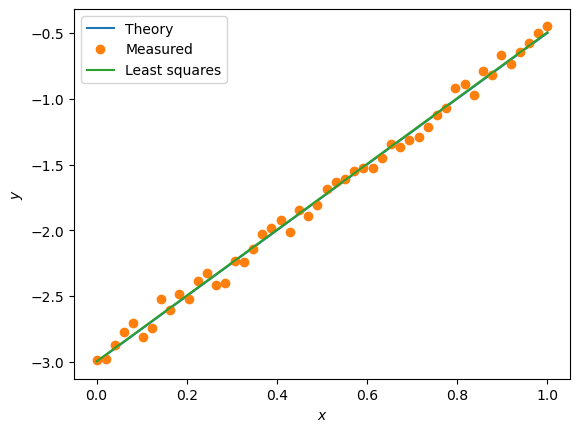

In [104]:
plt.plot(x, y, label='Theory')
plt.plot(x, y_noisy, 'o', label='Measured')
plt.plot(x, a_lstsq*x + b_lstsq, label='Least squares')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend();